# Predict Future Stock Prices (Short-Term)

## 1. Import

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 2. Load Dataset

In [2]:
data = yf.download('GOOGL', start='2016-01-01', end='2026-01-01')
data.columns = [col[0] for col in data.columns]
print("Shape:", data.shape)
data.head()

[*********************100%***********************]  1 of 1 completed

Shape: (2514, 5)


,Close,High,Low,Open,Volume
Date,,,,,
2016-01-04,37.660736,37.797605,37.070612,37.797605,67382000
2016-01-05,37.764381,38.144737,37.472793,37.891830,45216000
2016-01-06,37.655277,37.972654,37.093423,37.210952,48206000
2016-01-07,36.746292,37.455927,36.462637,37.018544,63132000
2016-01-08,36.245930,37.198555,36.147243,37.083505,47506000


## 3. Preparing and Splitin

In [3]:
data['Price'] = data['Close'].shift(-1)
data.dropna(inplace=True)

X = data[['Open', 'High', 'Low', 'Volume', 'Close']]
y = data['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

## 4. Model Training and Prediction

In [4]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

## 5. Evaluation

In [5]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Dataset 1")
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")

Dataset 1
MAE: 2.5840948633560865
RMSE: 3.643129161341608


## 6. Visualization

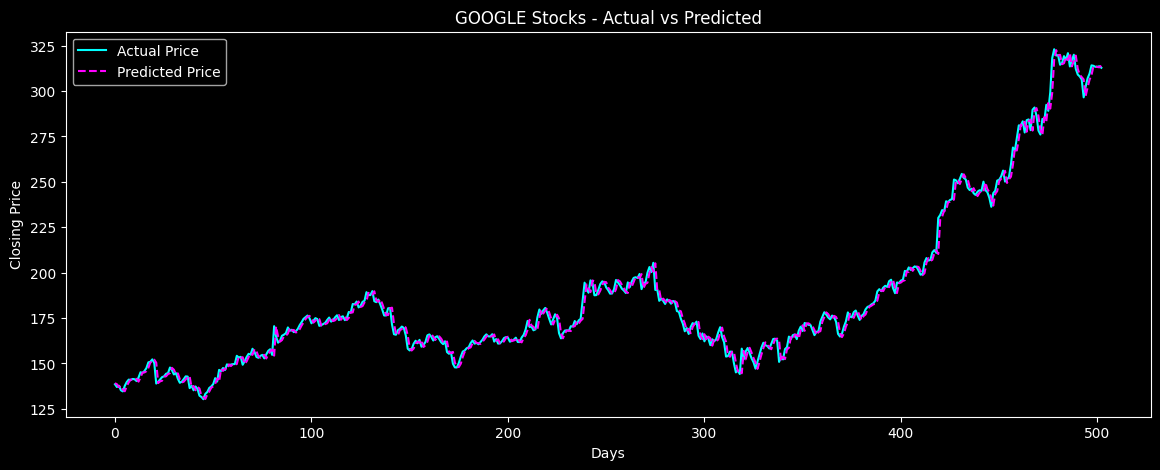

In [6]:
plt.style.use("dark_background")
plt.figure(figsize=(14, 5))
plt.plot(y_test.values, color='#00FFFF', label='Actual Price', linewidth=1.5)
plt.plot(y_pred, color='#FF00FF', label='Predicted Price', linewidth=1.5, linestyle='--')
plt.title('GOOGLE Stocks - Actual vs Predicted')
plt.xlabel('Days')
plt.ylabel('Closing Price')
plt.legend()
plt.show()

### *Note:-*
#### Very Consistent Results and almost perfect model